In [ ]:
!pip install pandas scikit-learn matplotlib seaborn

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
df = pd.read_csv("/content/ml_assignment6_dataset.csv")

In [ ]:
#Display First 5 Rows
df.head()

,age,study_hours,attendance,previous_grade,gender,internet_access,final_result
0,24,2.77,92,57.02,Female,Yes,Fail
1,21,3.12,93,51.62,Female,Yes,Fail
2,22,1.72,78,61.77,Male,No,Fail
3,24,3.23,62,48.40,Female,Yes,Fail
4,20,4.66,61,82.28,Female,Yes,Pass


In [ ]:
#Display Dataset Shape
df.shape

(200, 7)

In [ ]:
#Identify Feature Columns and Target Variable
X = df.drop("final_result", axis=1)
y = df["final_result"]

In [ ]:
#Check Missing Values
df.isnull().sum()

,0
age,0
study_hours,0
attendance,0
previous_grade,0
gender,0
internet_access,0
final_result,0


In [ ]:
#Verify Class Distribution
df["final_result"].value_counts()

,count
final_result,
Fail,100
Pass,100


In [ ]:
# 1. Data Preprocessing
df.fillna(df.mean(numeric_only=True), inplace=True)

In [ ]:
#Encode Categorical Features
le = LabelEncoder()

df["gender"] = le.fit_transform(df["gender"])
df["internet_access"] = le.fit_transform(df["internet_access"])
df["final_result"] = le.fit_transform(df["final_result"])

In [ ]:
#Feature Scaling
scaler = StandardScaler()

X = df.drop("final_result", axis=1)
y = df["final_result"]

X_scaled = scaler.fit_transform(X)

In [ ]:
#Verify Transformed Dat
X_scaled[:5]

array([[ 1.41657682, -0.62967459,  1.18908089, -0.81661482, -1.05131497,
         1.        ],
       [-0.08509472, -0.33331729,  1.25981741, -1.33493893, -1.05131497,
         1.        ],
       [ 0.41546246, -1.51874648,  0.19876962, -0.36068159,  0.95118973,
        -1.        ],
       [ 1.41657682, -0.24017642, -0.93301469, -1.64401367, -1.05131497,
         1.        ],
       [-0.5856519 ,  0.97065483, -1.00375121,  1.60799014, -1.05131497,
         1.        ]])

In [ ]:
#Save Preprocessed Dataset
processed = pd.DataFrame(X_scaled, columns=X.columns)
processed["final_result"] = y

processed.to_csv("processed_dataset.csv", index=False)

In [ ]:
#Compare Raw vs Processed Data
df.head()

processed.head()

,age,study_hours,attendance,previous_grade,gender,internet_access,final_result
0,1.416577,-0.629675,1.189081,-0.816615,-1.051315,1.0,0
1,-0.085095,-0.333317,1.259817,-1.334939,-1.051315,1.0,0
2,0.415462,-1.518746,0.198770,-0.360682,0.951190,-1.0,0
3,1.416577,-0.240176,-0.933015,-1.644014,-1.051315,1.0,0
4,-0.585652,0.970655,-1.003751,1.607990,-1.051315,1.0,1


In [ ]:
#2. Train-Test Split
#Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
#Verify Shapes
print(X_train.shape)
print(X_test.shape)

(160, 6)
(40, 6)


In [ ]:
# 3. Model Training
# Logistic Regression Model
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
#KNN Model
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
# Predict on Test Data
log_pred = log_model.predict(X_test)

knn_pred = knn_model.predict(X_test)

In [ ]:
# Compare Model Outputs
print(log_pred[:10])
print(knn_pred[:10])

[1 1 1 1 1 0 0 1 0 1]
[1 1 1 0 1 0 1 1 0 1]


In [ ]:
# Store Predictions
predictions = pd.DataFrame({
    "Actual": y_test,
    "Logistic": log_pred,
    "KNN": knn_pred
})

predictions.head()

,Actual,Logistic,KNN
95,1,1,1
15,1,1,1
30,1,1,1
158,1,1,0
128,1,1,1


In [ ]:
# 4. Model Evaluation
# Accuracy Score
print("Logistic Accuracy:", accuracy_score(y_test, log_pred))
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

Logistic Accuracy: 0.725
KNN Accuracy: 0.675


In [ ]:
#Classification Report
print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

           0       0.70      0.74      0.72        19
           1       0.75      0.71      0.73        21

    accuracy                           0.72        40
   macro avg       0.72      0.73      0.72        40
weighted avg       0.73      0.72      0.73        40



In [ ]:
#Confusion Matrix
cm = confusion_matrix(y_test, log_pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.show()

In [ ]:
#Misclassified Sample
misclassified = y_test != log_pred

print(sum(misclassified))

11


In [ ]:
#  5. Model Optimization
# K-Fold Cross Validation
from sklearn.model_selection import cross_val_score

scores = cross_val_score(log_model, X_scaled, y, cv=5)

scores.mean()

np.float64(0.71)

In [ ]:
#Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

param_grid = {"n_neighbors":[3,5,7,9]}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 7, 9]})

In [ ]:
#Best Hyperparameters
grid.best_params_

{'n_neighbors': 7}

In [ ]:
#Retrain Optimized Model
best_knn = grid.best_estimator_

best_knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=7)

In [ ]:
#Compare Baseline vs Optimized
best_pred = best_knn.predict(X_test)

accuracy_score(y_test, best_pred)

0.6

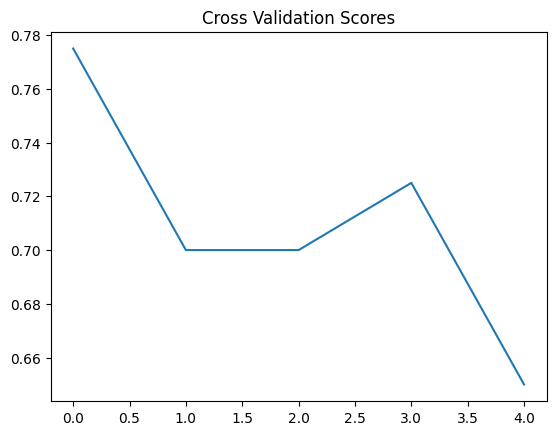

In [ ]:
#Plot Validation Scores
plt.plot(scores)

plt.title("Cross Validation Scores")

plt.show()

In [ ]:
# Model Interpretation
#Model Coefficients
log_model.coef_

array([[-0.15324641,  1.19274808,  0.69045473,  0.68675505,  0.15582156,
        -0.09068078]])